## Import

In [1]:
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from titanic.data import load_processed_data
from titanic.selection import select_model_features, FEATURE_SETS
from titanic.preprocessing import preprocess_train_test
from titanic.models import get_baseline_models
from titanic.validation import benchmark_models

## Data loading

In [2]:
df = load_processed_data()

print(df.shape)
df.head()

(1309, 41)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,HasNickname,SexIsMale,IsAlone,HasFamily,FamilySize,TicketText,TicketNumber,TicketNumberClass,HasCabin,Deck,CabinNumber,CabinCount,SurnameValueCounts,FamilySizeValueCounts,CabinValueCounts,TicketValueCounts,FareValueCounts,FarePerTicketPassenger,FarePerTicketPassenger_log1p,GroupSize,GroupType,FarePerPerson,FarePerPerson_log1p,AgeETR,AgeGroup,AgeDecade,IsChild
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,1,0,1,2,A5,21171,2,0,NaN,NaN,0,2,235,NaN,1,18,7.25000,2.110213,2,couple,3.625000,1.531476,22.0,young_adult,20-29,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0,0,1,2,PC,17599,1,1,C,85.0,1,2,235,2.0,2,2,35.64165,3.601186,2,couple,35.641650,3.601186,38.0,adult,30-39,0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0,1,0,1,STONO2,3101282,3,0,NaN,NaN,0,1,790,NaN,1,23,7.92500,2.188856,3,family,2.641667,1.292441,26.0,adult,20-29,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0,0,1,2,NaN,113803,1,1,C,123.0,1,2,235,2.0,2,6,26.55000,3.316003,2,couple,26.550000,3.316003,35.0,adult,30-39,0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,1,1,0,1,NaN,373450,3,0,NaN,NaN,0,2,790,NaN,1,61,8.05000,2.202765,1,single,8.050000,2.202765,35.0,adult,30-39,0


In [3]:
train_df = df[df["Survived"].notna()].copy()
test_df = df[df["Survived"].isna()].copy()

print("train:", train_df.shape)
print("test:", test_df.shape)

train: (891, 41)
test: (418, 41)


In [4]:
df_model = select_model_features(
    df,
    feature_set="base",
    include_target=True
)

features = [
    col for col in df_model.columns
    if col != "Survived"
]

features

['Pclass',
 'Title',
 'HasNickname',
 'SexIsMale',
 'AgeETR',
 'AgeGroup',
 'SibSp',
 'Parch',
 'GroupType',
 'FarePerPerson_log1p',
 'Deck',
 'HasCabin']

## Preprocessing

In [5]:
X_train, y_train, X_test, preprocessor = preprocess_train_test(
    df_model,
    features=features,
    target="Survived",
    scale_numeric=True
)

feature_names = preprocessor.get_feature_names_out()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

X_train: (891, 31)
y_train: (891,)
X_test: (418, 31)


## Benchmark du feature set actuel

In [6]:
models = get_baseline_models(random_state=42)

benchmark_base = benchmark_models(
    models=models,
    X=X_train,
    y=y_train,
    scoring="accuracy",
    n_splits=10,
    random_state=42
)

benchmark_base

,model,train_score_mean,train_score_std,test_score_mean,test_score_std
0,SVC,0.843371,0.004280,0.836092,0.029577
1,AdaBoostClassifier,0.841750,0.004929,0.831598,0.032756
2,GradientBoostingClassifier,0.900860,0.006327,0.829338,0.036019
3,LogisticRegression,0.839755,0.005182,0.825980,0.030485
4,KNeighborsClassifier,0.870058,0.004458,0.819288,0.024946
5,BaggingClassifier,0.973189,0.003706,0.818102,0.032756
6,XGBClassifier,0.979673,0.003009,0.813695,0.039291
7,RandomForestClassifier,0.989275,0.001143,0.812534,0.029931
8,ExtraTreesClassifier,0.989275,0.001143,0.793446,0.028769
9,GaussianNB,0.787629,0.005671,0.783346,0.043993


## Random Forest feature importance

In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

rf_importance.head(30)

,feature,importance
0,num__AgeETR,0.190678
1,num__FarePerPerson_log1p,0.189526
2,cat__Title_Mr,0.122809
3,num__SexIsMale,0.088058
4,num__Pclass,0.054366
5,cat__Title_Miss,0.040671
6,num__HasNickname,0.038054
7,num__SibSp,0.036338
8,cat__Title_Mrs,0.032607
9,num__HasCabin,0.024798


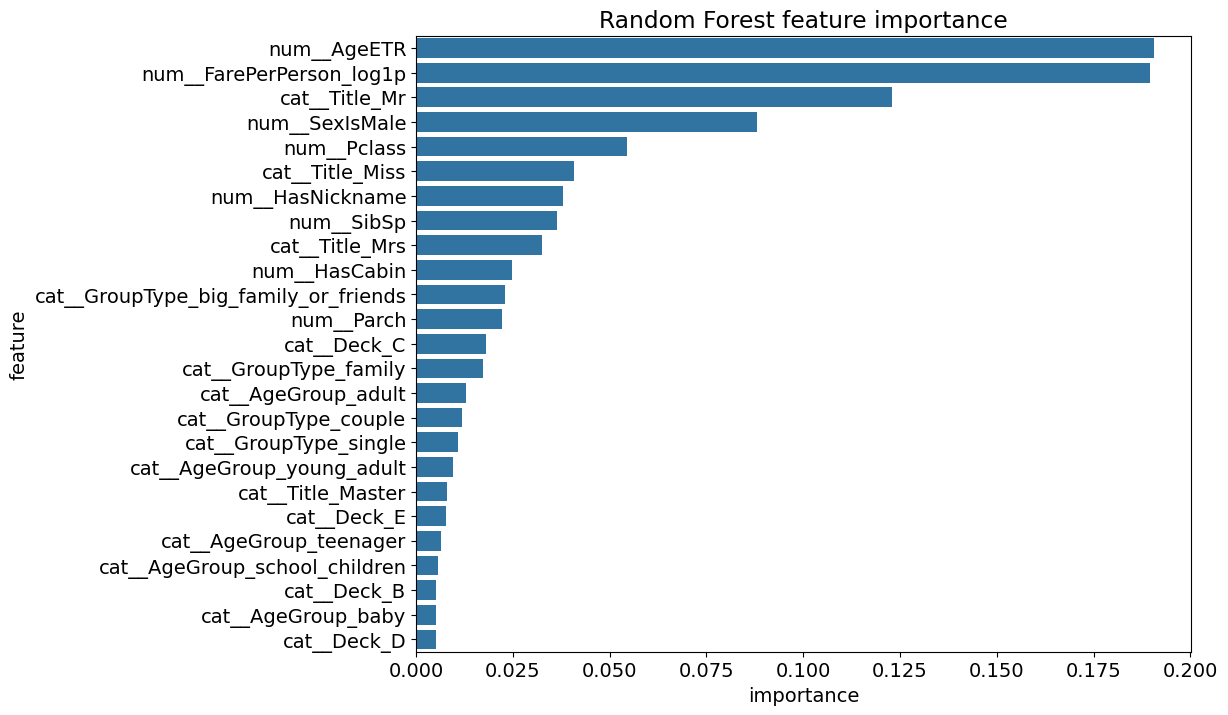

In [8]:
top_n = 25

plt.figure(figsize=(10, 8))

sns.barplot(
    data=rf_importance.head(top_n),
    x="importance",
    y="feature"
)

plt.title("Random Forest feature importance")
plt.show()

## Permutation importance

In [9]:
perm = permutation_importance(
    rf,
    X_train,
    y_train,
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

perm_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

perm_importance.head(30)

,feature,importance_mean,importance_std
0,num__FarePerPerson_log1p,0.099252,0.006561
1,num__AgeETR,0.088851,0.007624
2,cat__Title_Mr,0.078788,0.005856
3,num__Pclass,0.064123,0.006247
4,num__HasCabin,0.026038,0.002918
5,cat__AgeGroup_adult,0.024055,0.003474
6,num__SibSp,0.022297,0.004543
7,cat__GroupType_single,0.021549,0.003031
8,cat__GroupType_couple,0.019716,0.003236
9,num__HasNickname,0.019566,0.002257


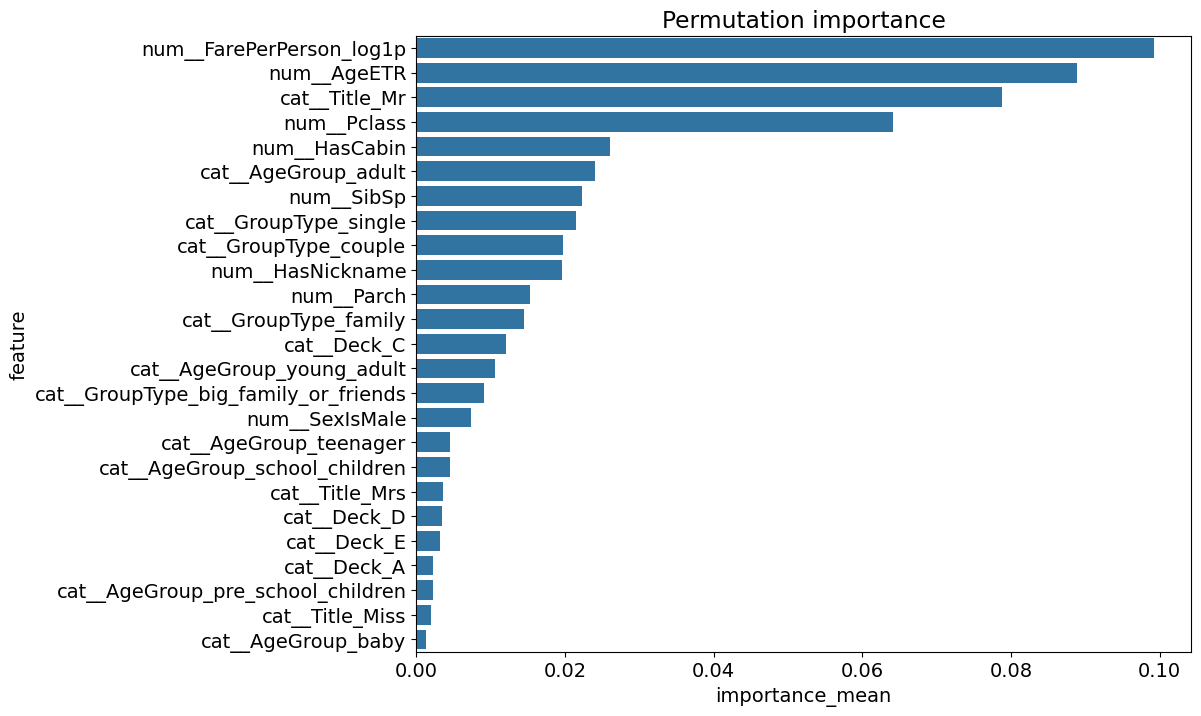

In [10]:
top_n = 25

plt.figure(figsize=(10, 8))

sns.barplot(
    data=perm_importance.head(top_n),
    x="importance_mean",
    y="feature"
)

plt.title("Permutation importance")
plt.show()

## Comparaison RF importance et permutation importance

In [11]:
importance_comparison = (
    rf_importance
    .merge(perm_importance, on="feature", how="left")
    .sort_values("importance_mean", ascending=False)
)

importance_comparison.head(30)

,feature,importance,importance_mean,importance_std
1,num__FarePerPerson_log1p,0.189526,0.099252,0.006561
0,num__AgeETR,0.190678,0.088851,0.007624
2,cat__Title_Mr,0.122809,0.078788,0.005856
4,num__Pclass,0.054366,0.064123,0.006247
9,num__HasCabin,0.024798,0.026038,0.002918
14,cat__AgeGroup_adult,0.013004,0.024055,0.003474
7,num__SibSp,0.036338,0.022297,0.004543
16,cat__GroupType_single,0.010710,0.021549,0.003031
15,cat__GroupType_couple,0.011867,0.019716,0.003236
6,num__HasNickname,0.038054,0.019566,0.002257


## Corrélation avec Survived

In [12]:
corr_with_target = (
    train_df
    .corr(numeric_only=True)["Survived"]
    .sort_values(ascending=False)
)

corr_with_target

Survived                        1.000000
HasNickname                     0.346496
HasCabin                        0.316912
FarePerPerson_log1p             0.307913
FarePerTicketPassenger_log1p    0.306219
FarePerTicketPassenger          0.288337
CabinCount                      0.283704
FarePerPerson                   0.259621
Fare                            0.257307
HasFamily                       0.203367
IsChild                         0.138047
CabinValueCounts                0.114854
Parch                           0.081629
TicketValueCounts               0.064962
FamilySize                      0.016639
PassengerId                    -0.005007
SurnameValueCounts             -0.025524
SibSp                          -0.035322
AgeETR                         -0.061691
CabinNumber                    -0.063747
Age                            -0.077221
GroupSize                      -0.083525
TicketNumber                   -0.095605
FareValueCounts                -0.176521
FamilySizeValueC

In [13]:
corr = train_df.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

strong_corr = (
    upper
    .stack()
    .reset_index()
)

strong_corr.columns = ["feature_1", "feature_2", "correlation"]

strong_corr = strong_corr.sort_values(
    "correlation",
    ascending=False
)

strong_corr.head(30)

,feature_1,feature_2,correlation
114,Age,AgeETR,1.000000
271,IsAlone,HasFamily,1.000000
279,IsAlone,FamilySizeValueCounts,0.985394
308,HasFamily,FamilySizeValueCounts,0.985394
663,FarePerTicketPassenger,FarePerPerson,0.914193
127,SibSp,FamilySize,0.890712
422,HasCabin,CabinCount,0.886133
661,FarePerTicketPassenger,FarePerTicketPassenger_log1p,0.873967
199,Fare,FarePerPerson,0.861398
693,FarePerTicketPassenger_log1p,FarePerPerson_log1p,0.854452


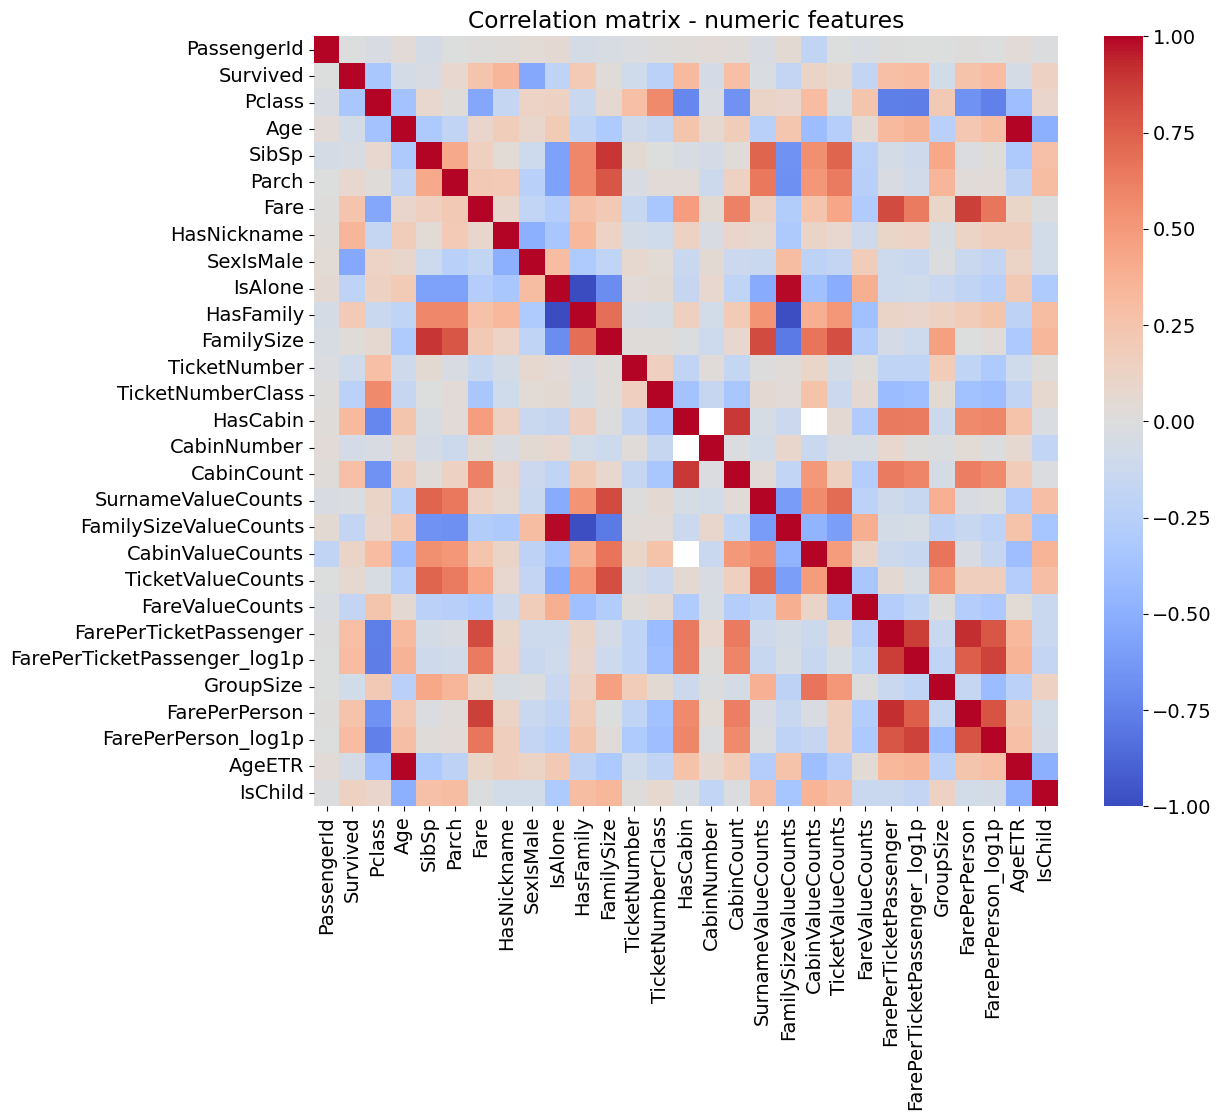

In [14]:
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12, 10))

sns.heatmap(
    train_df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix - numeric features")
plt.show()

## Fonction d’ablation study

In [15]:
def benchmark_feature_set(df, feature_set, model_name="SVC"):
    df_model = select_model_features(
        df,
        feature_set=feature_set,
        include_target=True
    )

    features = [
        col for col in df_model.columns
        if col != "Survived"
    ]

    X_train, y_train, X_test, preprocessor = preprocess_train_test(
        df_model,
        features=features,
        target="Survived",
        scale_numeric=True
    )

    models = get_baseline_models(random_state=42)

    benchmark = benchmark_models(
        models={model_name: models[model_name]},
        X=X_train,
        y=y_train,
        scoring="accuracy",
        n_splits=10,
        random_state=42
    )

    return {
        "feature_set": feature_set,
        "model": model_name,
        "score": benchmark.loc[0, "test_score_mean"],
        "std": benchmark.loc[0, "test_score_std"],
        "n_features_raw": len(features),
        "n_features_processed": X_train.shape[1]
    }

## Tester tous les feature sets existants

In [16]:
ablation_results = []

for feature_set in FEATURE_SETS.keys():
    result = benchmark_feature_set(
        df=df,
        feature_set=feature_set,
        model_name="SVC"
    )

    ablation_results.append(result)

ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

ablation_df

,feature_set,model,score,std,n_features_raw,n_features_processed
0,base,SVC,0.836092,0.029577,12,31
1,with_ticket,SVC,0.836092,0.026421,13,32
2,with_family,SVC,0.833858,0.025215,14,33
3,without_age_group,SVC,0.833845,0.029842,11,24
4,with_cabin,SVC,0.831598,0.030356,13,32


## Tester plusieurs modèles sur les feature sets

In [17]:
model_names = [
    "SVC",
    "AdaBoostClassifier",
    "LogisticRegression",
    "GradientBoostingClassifier"
]

all_results = []

for feature_set in FEATURE_SETS.keys():
    for model_name in model_names:
        result = benchmark_feature_set(
            df=df,
            feature_set=feature_set,
            model_name=model_name
        )
        all_results.append(result)

feature_model_results = (
    pd.DataFrame(all_results)
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

feature_model_results

,feature_set,model,score,std,n_features_raw,n_features_processed
0,with_family,AdaBoostClassifier,0.842834,0.032709,14,33
1,base,SVC,0.836092,0.029577,12,31
2,with_ticket,SVC,0.836092,0.026421,13,32
3,with_family,SVC,0.833858,0.025215,14,33
4,without_age_group,SVC,0.833845,0.029842,11,24
5,without_age_group,AdaBoostClassifier,0.832722,0.032539,11,24
6,with_cabin,SVC,0.831598,0.030356,13,32
7,base,AdaBoostClassifier,0.831598,0.032756,12,31
8,with_family,GradientBoostingClassifier,0.830474,0.032158,14,33
9,with_cabin,AdaBoostClassifier,0.830474,0.032158,13,32


## Pivot de comparaison

In [18]:
feature_model_results.pivot_table(
    index="feature_set",
    columns="model",
    values="score"
).sort_values("SVC", ascending=False)

model,AdaBoostClassifier,GradientBoostingClassifier,LogisticRegression,SVC
feature_set,,,,
base,0.831598,0.829338,0.825980,0.836092
with_ticket,0.829401,0.828215,0.830449,0.836092
with_family,0.842834,0.830474,0.825980,0.833858
without_age_group,0.832722,0.823733,0.828215,0.833845
with_cabin,0.830474,0.829351,0.824856,0.831598
